In [12]:
import numpy as np
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import csv
from matplotlib import cm
from collections import OrderedDict
cmaps = OrderedDict()

from sklearn.tree import DecisionTreeClassifier # imports the decission tree module from sklearn
from sklearn.model_selection import train_test_split # this module is used to split the data (eg 20% 80% test, train)
from sklearn.metrics import accuracy_score # this module is used to calculate the accuracy of the output
import joblib # this module is used to store the trained model instead or training it every time
from sklearn import preprocessing # this is modeule is used in this note to normalize the values of the datafram

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
# from keras.utils import np_utils
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error
# from sklearn.utils import check_arrays
import seaborn as sns

# from keras.layers.convolutional import *
from keras.layers import Flatten

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.gridspec import GridSpec
from skimage.metrics import structural_similarity as ssim

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Link note to my google drive
The path is used to locate my dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')
path = 'drive/My Drive/AI_Geotech/Combined_trainingSet'


Mounted at /content/drive


# Computational power

Check for GPU

In [2]:
%tensorflow_version 2.x
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Found GPU at: /device:GPU:0


GPU Information

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Select the Runtime > "Change runtime type" menu to enable a GPU accelerator, ')
  print('and then re-execute this cell.')
else:
  print(gpu_info)

Thu Jan 16 21:40:52 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   73C    P0              31W /  70W |    103MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

RAM information

In [3]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('To enable a high-RAM runtime, select the Runtime > "Change runtime type"')
  print('menu, and then select High-RAM in the Runtime shape dropdown. Then, ')
  print('re-execute this cell.')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

To enable a high-RAM runtime, select the Runtime > "Change runtime type"
menu, and then select High-RAM in the Runtime shape dropdown. Then, 
re-execute this cell.


In [4]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Load Data from files

In [5]:
!pwd
!cd drive
!ls

/content
drive  sample_data


In [11]:
path = 'drive/My Drive/paper2sec/AI_Geotech/Combined_trainingSet'
def check_folder_exists(folder_path):
    """
    Check if a folder exists at the specified path.

    Parameters:
        folder_path (str): The path of the folder to check.

    Returns:
        bool: True if the folder exists, False otherwise.
    """
return os.path.isdir(folder_path)

# Example usage:
folder_path = path
if check_folder_exists(folder_path):
    print(f"The folder '{folder_path}' exists.")
else:
    print(f"The folder '{folder_path}' does not exist.")

SyntaxError: 'return' outside function (<ipython-input-11-dc2913278336>, line 12)

In [ ]:
# opens the file using context manager
batch_size = 500
batches = range(0,160)
batch_len = len(list(batches))
data_models = np.empty((batch_len*batch_size, 24, 48, 1), dtype=np.float32)
data_transforms = np.empty((batch_len*batch_size, 400, 76, 1), dtype=np.float32)
for count, b in enumerate(batches):
     with h5py.File(path+f"/new_sor_{batch_size}sim_b{b}.hdf5", "r") as f:
        data_models[count*batch_size: (count+1)*batch_size] = f["models"][:]
        data_transforms[count*batch_size: (count+1)*batch_size] = f["transforms"][:].reshape(batch_size, 400, 76, 1)
print(f"data_models                   :  {data_models.shape}")
print(f"data_transforms                   :  {data_transforms.shape}")

data_models                   :  (10000, 24, 48, 1)
data_transforms                   :  (10000, 400, 76, 1)


Split Data into training (training + validation) and testing

In [ ]:
All_Data = batch_size * batch_len
training_models = data_models           #training output
training_transforms= data_transforms   #training intput
print(training_models.shape)
print(training_transforms.shape)

(80000, 24, 48, 1)
(80000, 400, 76, 1)


# Plot random models

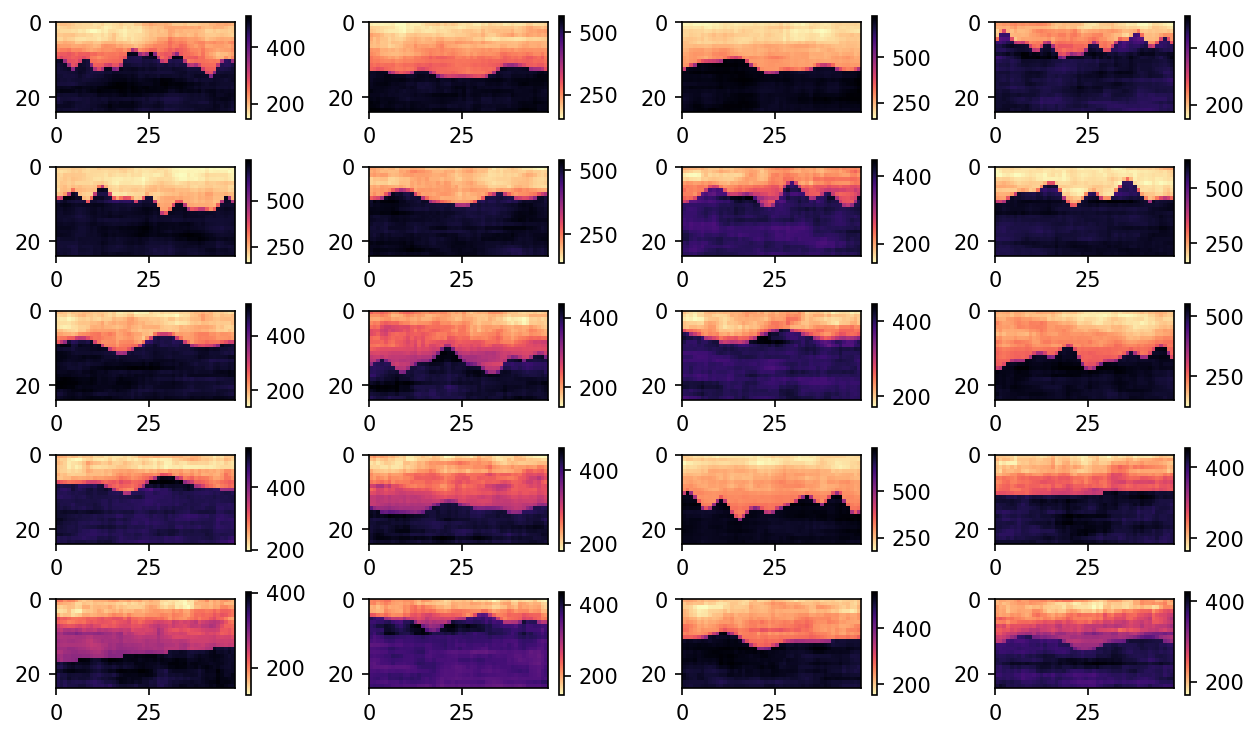

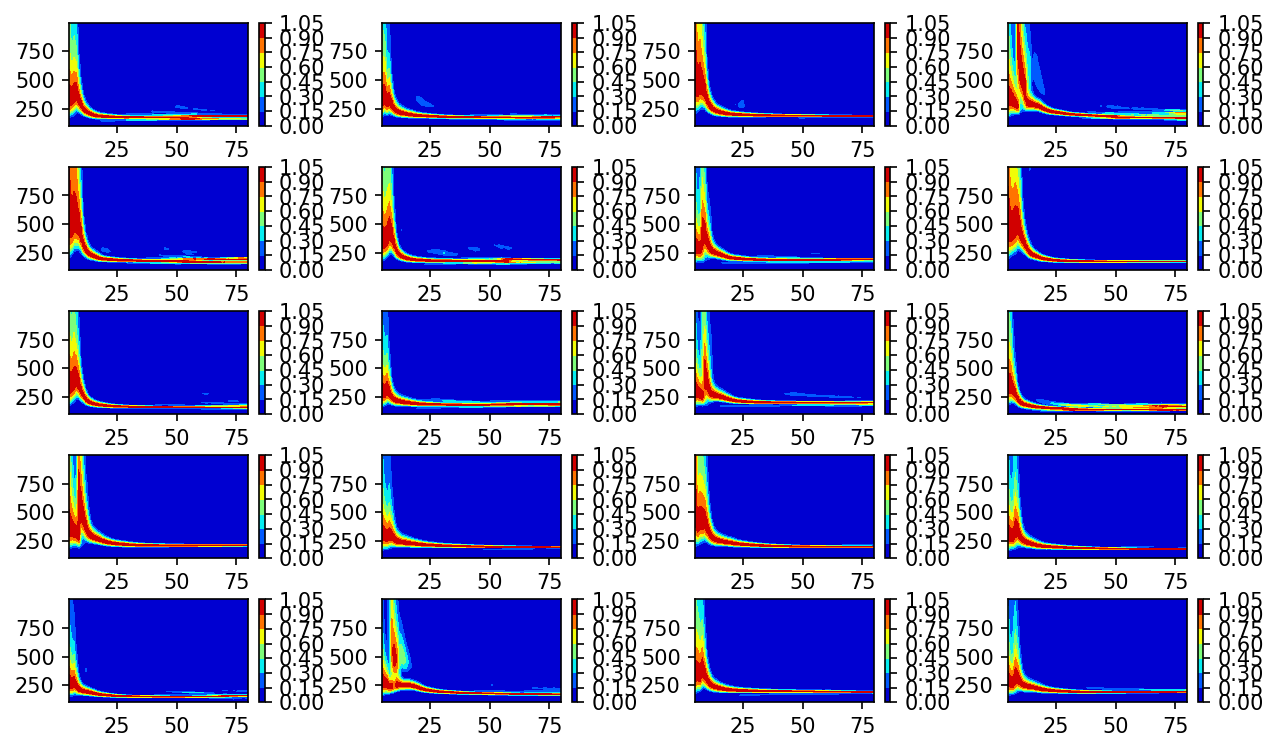

In [ ]:
columns=4
rows=5


modelNumber=[]
for i in range(columns*rows):
  RandomNumber = np.random.randint(0,All_Data)
  modelNumber.append(RandomNumber)

fig, ax = plt.subplots( rows, columns, figsize=(10, 6),dpi=150)
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(rows):
  for j in range(columns):
    model=data_models[modelNumber[j+(i*columns)],:,:,0]
    pcm = ax[i,j].imshow(model, extent=[0,48,24,0], aspect="equal", cmap='magma_r')
    fig.colorbar(pcm, ax=ax[i,j])

fig, ax = plt.subplots(rows, columns, figsize=(10, 6),dpi=150)
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(rows):
  for j in range(columns):
    transform = data_transforms[modelNumber[j+(i*columns)],:,:,0]
    pcm = ax[i,j].contourf(np.arange(5,81,1), np.arange(100,1000,2.25), transform, cmap="jet")
    fig.colorbar(pcm, ax=ax[i,j])